In [43]:
import os
import logging
import json
import cv2

from tqdm import tqdm
import numpy as np
from pathlib import Path
import argparse
import sys
import importlib.util
import importlib.machinery
from datetime import datetime

%load_ext autoreload
%autoreload 2

# map package name → alternative path
ALT_MODULE_PATHS = {
    "face_detection": "/mnt/ssd/workspace/adi/vh_repos_byversion/face-detection/3-0-0/face-production-face-detection/face_detection"
}

class AltImportFinder(importlib.abc.MetaPathFinder):
    def find_spec(self, fullname, path, target=None):
        if fullname in ALT_MODULE_PATHS:
            alt_path = Path(ALT_MODULE_PATHS[fullname])
            init_file = alt_path / "__init__.py"
            if not init_file.exists():
                return None
            loader = importlib.machinery.SourceFileLoader(fullname, str(init_file))
            return importlib.util.spec_from_loader(fullname, loader, origin=str(init_file))
        return None

# install our custom finder at the front
finder = AltImportFinder()
if not any(isinstance(f, AltImportFinder) for f in sys.meta_path):
    sys.meta_path.insert(0, finder)

from face_detection import FaceDetection
import matplotlib.pyplot as plt
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# 1. Read JSON source OR folder dir
def get_source_paths(base_dir):
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp')
    file_list = []

    #for (root,dirs,files) in os.walk(base_dir):
    #    for file in files:
    #        file_list.append(file)
    #    root = root
    file_list = os.listdir(base_dir)         
    file_list = [f for f in file_list if f.lower().endswith(valid_exts)]

    return base_dir, file_list

In [62]:
base_dir = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/e4s_20251103"

In [63]:
root,list_files = get_source_paths(base_dir)

In [64]:
def read_align_image(fd, image_path):
    # Read the image
    img = cv2.imread(image_path)
    # Check if the image was successfully loaded
    if img is None:
        return None, None, None
    
    # Use FD 3.0.0
    # Perform face detection
    dets, angle = fd.predict(img, strict_level="low")
    if len(dets) <= 0:
        return None, None, None
    
    img_cropped = fd.extract_face(img, dets, angle, task="face-iso", return_bbox=True, loose_factor = 1)
    #img_cropped = fd.extract_face(img, dets, angle, task="face-iso", return_bbox=True, loose_factor = 1.5)
    
    # Convert NumPy arrays to lists
    dets = dets.tolist() if isinstance(dets, np.ndarray) else dets
    angle = angle.tolist() if isinstance(angle, np.ndarray) else angle

    return img_cropped, dets, angle

In [65]:
image_path = os.path.join(root, list_files[0])

In [66]:
fd = FaceDetection()
img_cropped, dets, angle = read_align_image(fd,image_path)

Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.


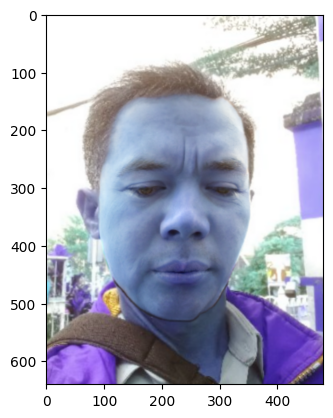

In [67]:
plt.imshow(img_cropped)

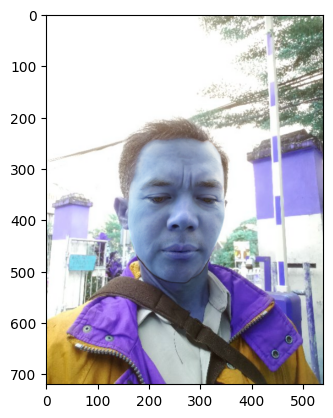

In [68]:
plt.imshow(cv2.imread(image_path))